# Model Training, Testing and Evaluation

In [54]:
import pandas as pd
import numpy as np
import os
import joblib
import json
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [55]:
os.makedirs("../../models/plots", exist_ok=True)

train_df = pd.read_parquet("../data/processed/final/train_set.parquet")
test_df  = pd.read_parquet("../data/processed/final/test_set.parquet")

with open('../../models/address_features_metadata.json', 'r') as f:
    meta = json.load(f)

onchain_features  = meta['onchain_features']
market_features   = meta['market_features']
reddit_features   = meta['reddit_features']
twitter_features  = meta['twitter_features']

ALL_FEATURES = onchain_features + market_features + reddit_features + twitter_features
TARGET = 'is_scam'

### Train/test split

In [56]:
X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_test, y_test   = test_df[ALL_FEATURES], test_df[TARGET]

print(f"\nFeatures: {len(ALL_FEATURES)} features (On-chain:{len(onchain_features)} Market:{len(market_features)} Reddit:{len(reddit_features)} Twitter:{len(twitter_features)})")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train scam ratio: {y_train.mean():.2%}")
print(f"Test scam ratio:  {y_test.mean():.2%}")


Features: 34 features (On-chain:19 Market:3 Reddit:5 Twitter:7)
Train: 28217, Test: 7055
Train scam ratio: 16.28%
Test scam ratio:  16.27%


### Classifier Comparison

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
}

for name, clf in classifiers.items():
    if name == 'Logistic Regression':
        clf.fit(X_train_scaled, y_train)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:20s}: AUC = {auc:.4f}, F1 = {f1:.4f}")

Logistic Regression : AUC = 0.8593, F1 = 0.6071
Random Forest       : AUC = 0.9557, F1 = 0.8283
XGBoost             : AUC = 0.9598, F1 = 0.8366


### Train XGBoost Model

In [58]:
final_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
)
final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Predictions

In [59]:
y_train_pred = (final_model.predict_proba(X_train)[:, 1] >= 0.5).astype(int)
y_test_prob  = final_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_prob >= 0.5).astype(int)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTRAIN SET")
print(classification_report(y_train, y_train_pred))
print("TEST SET")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Scam']))

gap = train_f1 - test_f1
print(f"Gap: {gap:.4f}")


TRAIN SET
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     23623
           1       0.96      0.85      0.90      4594

    accuracy                           0.97     28217
   macro avg       0.97      0.92      0.94     28217
weighted avg       0.97      0.97      0.97     28217

TEST SET
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      5907
        Scam       0.91      0.78      0.84      1148

    accuracy                           0.95      7055
   macro avg       0.93      0.88      0.90      7055
weighted avg       0.95      0.95      0.95      7055

Gap: 0.0632


### Ablation Study

In [60]:
configs = [
    {'name': 'On-Chain Only',       'features': onchain_features},
    {'name': 'On-Chain + Market',   'features': onchain_features + market_features},
    {'name': 'On-Chain + Reddit',   'features': onchain_features + reddit_features},
    {'name': 'On-Chain + Twitter',  'features': onchain_features + twitter_features},
    {'name': 'Full Multimodal',     'features': ALL_FEATURES},
]

results = []
for config in configs:
    feats = config['features']
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=1,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
    model.fit(X_train[feats], y_train)
    y_prob = model.predict_proba(X_test[feats])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results.append({
        'Model':     config['name'],
        'Features':  len(feats),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'AUC':       roc_auc_score(y_test, y_prob),
    })

abl_df = pd.DataFrame(results)
abl_df['AUC_Change'] = abl_df['AUC'] - abl_df.iloc[0]['AUC']
print("\nAblation Study Results")
print(abl_df.to_string(index=False))


Ablation Study Results
             Model  Features       F1  Precision   Recall      AUC  AUC_Change
     On-Chain Only        19 0.686254   0.862797 0.569686 0.919517    0.000000
 On-Chain + Market        22 0.722418   0.856631 0.624564 0.935358    0.015841
 On-Chain + Reddit        24 0.802657   0.881250 0.736934 0.955353    0.035836
On-Chain + Twitter        26 0.825201   0.904465 0.758711 0.958523    0.039006
   Full Multimodal        34 0.837166   0.907426 0.777003 0.962252    0.042735


### Ablation plot

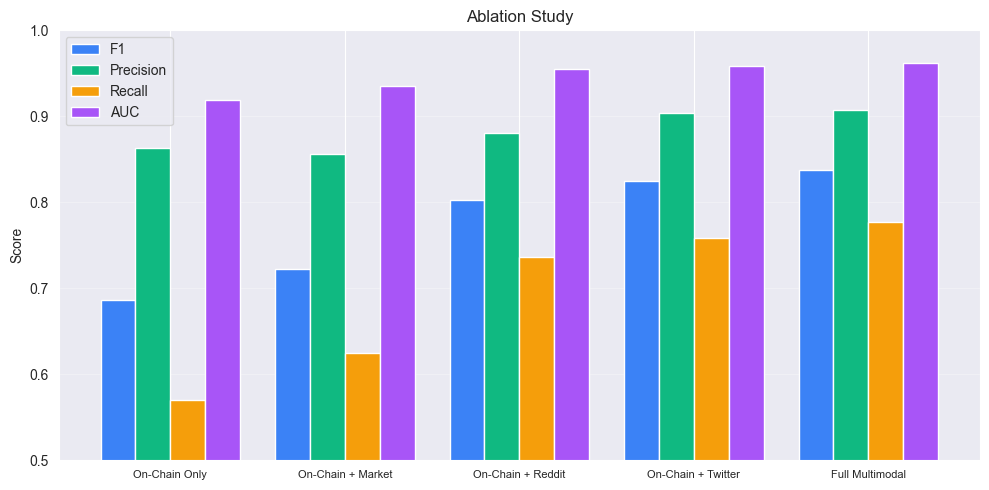

In [61]:
metrics = ['F1', 'Precision', 'Recall', 'AUC']
colors  = ['#3b82f6', '#10b981', '#f59e0b', '#a855f7']

x = range(len(abl_df))
plt.figure(figsize=(10,5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([xi + (i-1.5)*0.2 for xi in x], abl_df[metric], 0.2, color=color, label=metric)

plt.xticks(x, abl_df['Model'], fontsize=8)
plt.ylabel("Score")
plt.title("Ablation Study")
plt.ylim(0.5,1.0)
plt.grid(alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig("../../models/plots/ablation.png", dpi=150)
plt.show()

### Evaluation Plots

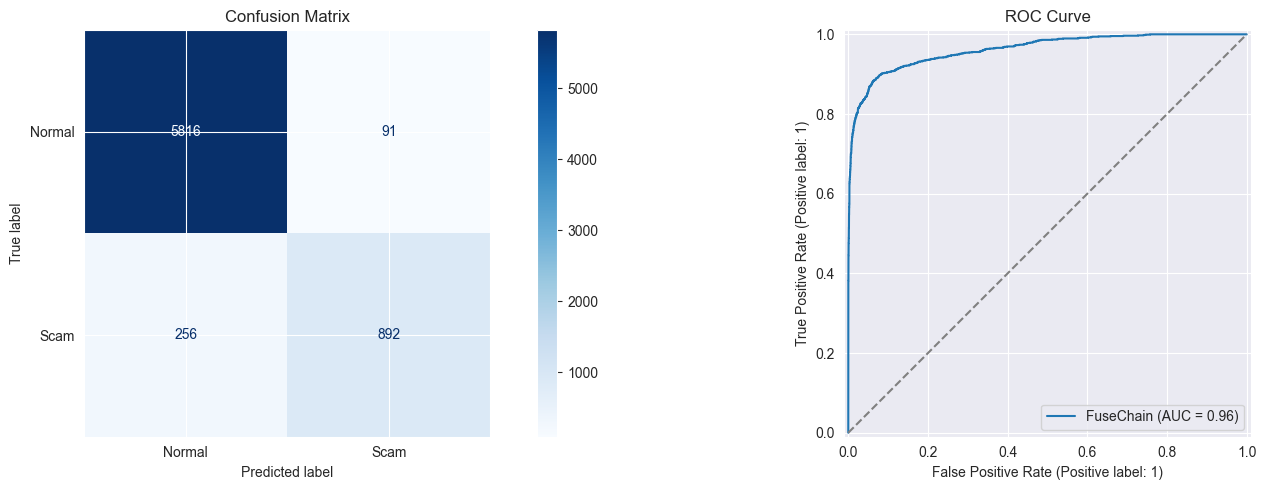

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Normal','Scam'], cmap='Blues', ax=axes[0])

axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1], name="FuseChain")

axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.savefig("../../models/plots/evaluation.png", dpi=150)
plt.show()

### SHAP Analysis

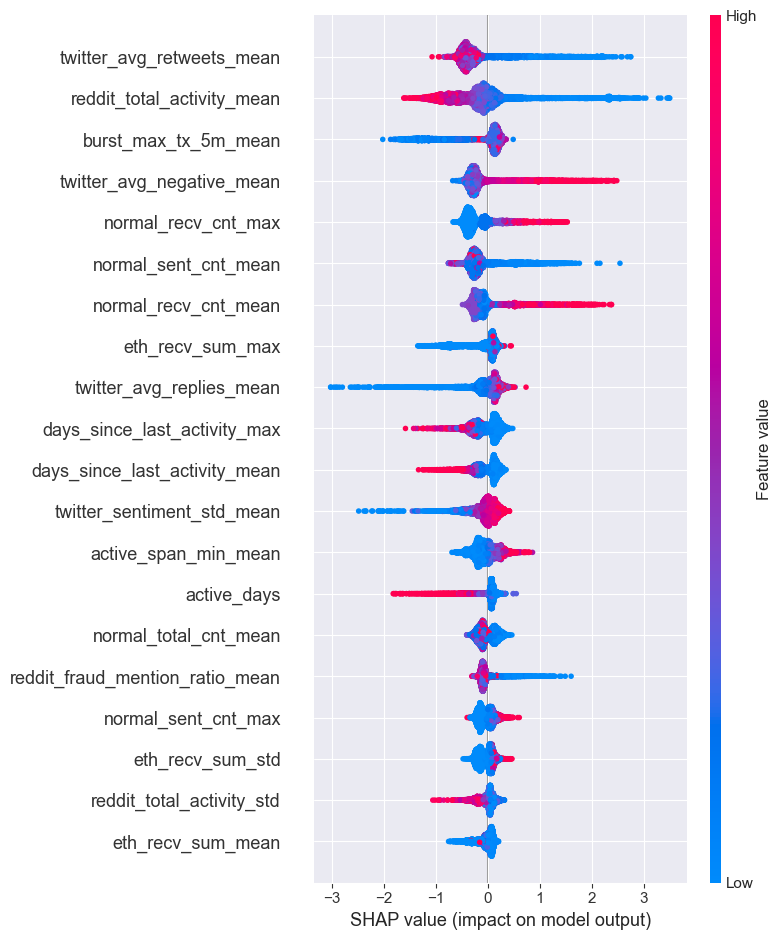

In [63]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

#Beeswarm plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../../models/plots/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

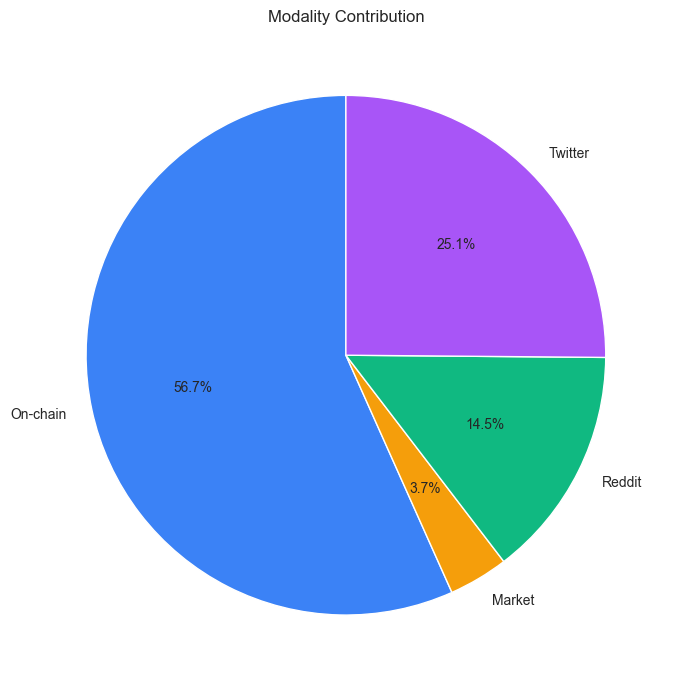

In [64]:
mean_shap = np.abs(shap_values).mean(axis=0)

# Sum by modality
mod_totals = {"On-chain":0, "Market":0, "Reddit":0, "Twitter":0}
for f, v in zip(X_test.columns, mean_shap):
    if f.startswith('market_'):    mod_totals["Market"] += v
    elif f.startswith('reddit_'):  mod_totals["Reddit"] += v
    elif f.startswith('twitter_'): mod_totals["Twitter"] += v
    else:                          mod_totals["On-chain"] += v

plt.figure(figsize=(7,7))
plt.pie(mod_totals.values(), labels=mod_totals.keys(),
        colors=['#3b82f6','#f59e0b','#10b981','#a855f7'],
        autopct='%1.1f%%', startangle=90)
plt.title("Modality Contribution")
plt.tight_layout()
plt.savefig("../../models/plots/modality_pie.png", dpi=150)
plt.show()

### Save Model

In [65]:
os.makedirs("../../models", exist_ok=True)
model_artifact = {
    'model': final_model,
    'feature_columns': ALL_FEATURES,
    'target_column': TARGET
}
joblib.dump(model_artifact, "../../models/xgboost_address_model.joblib")
print("Model saved")

Model saved


### Demo Addresses

In [66]:
demo_scams = test_df[test_df['is_scam'] == 1].sample(10, random_state=42)
demo_normals = test_df[test_df['is_scam'] == 0].sample(10, random_state=42)

demo = pd.concat([demo_scams, demo_normals])
demo[['address', 'is_scam']].to_csv("../../models/demo_labeled_addresses.csv", index=False)
demo[['address']].to_csv("../../models/demo_unlabeled_addresses.csv", index=False)

print("test files saved")

test files saved
